# Case based learning

What can we do with Cheminformatics:
1) Structural Information
2) Molecular Descriptor 
3) Structural FingerPrints
4) Substructure Search
5) Similarity Searching 
6) Chemical Database Navigation
7) Property Prediction 
8) Reaction Informatics
9) Chemical Space Exploration
10) Dataset Generation and making AI pipelines

In this notebook we will explore concepts in cheminformatics and (hopefully) 80-90% of mostly used RDKit functionality by

circling around a few molecules which are :
1) Ethanol (simple organic molecule)
2) Benzene (aromatic chemistry)
3) Aspirin (drug like molecule)
4) Glucose (biomolecule)
5) Caffeine (heterocycles, nitrogen-rich structure, drug-like-capacity)
6) Silane (inorganic molecule)
7) Chlorosilane (inorganic molecule)
8) Silicone dioxide (inorganic molecule)
9) Carbon dioxide
10) Siloxane



In [2]:
# Setup
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs

In [3]:
# making SMILES for molecules

ethanol = Chem.MolFromSmiles('CCO')
benzene = Chem.MolFromSmiles('c1ccccc1')
aspirin = Chem.MolFromSmiles('CC(=O)OC1=CC=CC=C1C(=O)O')
glucose = Chem.MolFromSmiles('C(C1C(C(C(C(O1)O)O)O)O)O')
caffeine = Chem.MolFromSmiles('Cn1cnc2c1c(=O)n(c(=O)n2C)C')
silane = Chem.MolFromSmiles('[SiH4]')
chlorosilane = Chem.MolFromSmiles('[SiH](Cl)(Cl)(Cl)')
silicone_dioxide = Chem.MolFromSmiles('O[Si](O)(O)O')
carbon_dioxide = Chem.MolFromSmiles('O=C=O')
siloxane = Chem.MolFromSmiles('O[Si](O)(O)O[Si](O)(O)O')

# Visualising the molecules

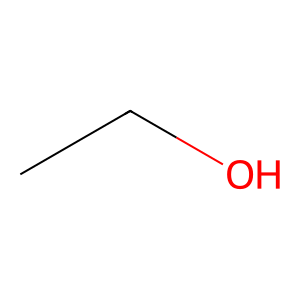

In [4]:
Draw.MolToImage(ethanol)

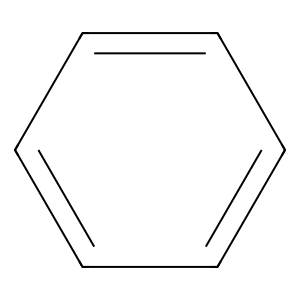

In [5]:
Draw.MolToImage(benzene)

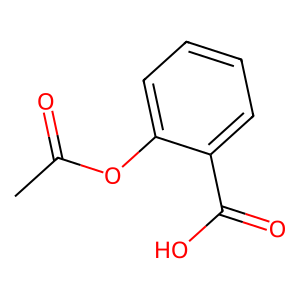

In [6]:
Draw.MolToImage(aspirin)

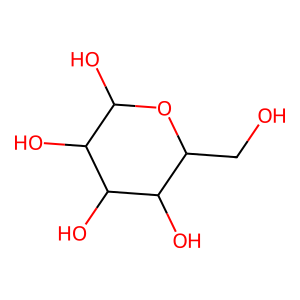

In [7]:
Draw.MolToImage(glucose)

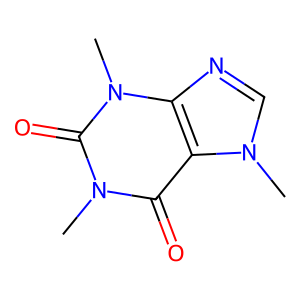

In [8]:
Draw.MolToImage(caffeine)

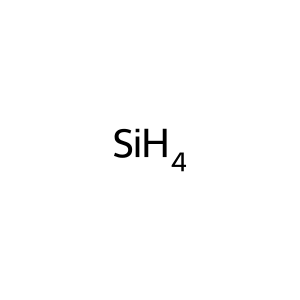

In [9]:
Draw.MolToImage(silane)

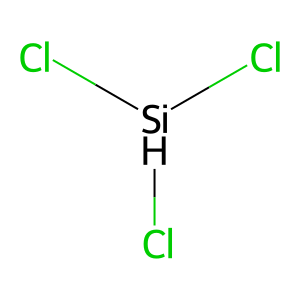

In [10]:
Draw.MolToImage(chlorosilane)

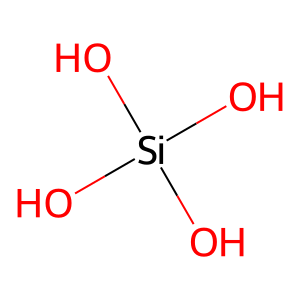

In [11]:
Draw.MolToImage(silicone_dioxide)

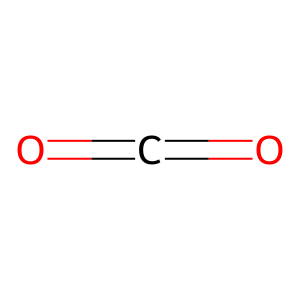

In [12]:
Draw.MolToImage(carbon_dioxide)

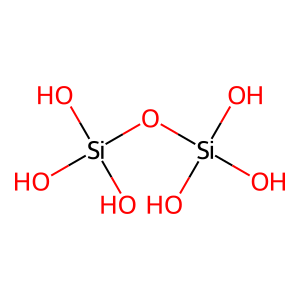

In [13]:
Draw.MolToImage(siloxane)

# 1 Structural Information 
Basic structural facts

* Atoms present
* Bond types
* Ring structures 
* Aromaticity 
* Functional Groups
* Stereochemistry

We mainly use `rdkit.Chem` and `rdkit.Chem.Draw`

In [14]:
# Necessary libraries
from rdkit import Chem
from rdkit.Chem import Draw

In [15]:
# We can just make again the molecules from above

# Convert SMILES format into molecular graph 
ethanol =  Chem.MolFromSmiles("CCO")
benzene = Chem.MolFromSmiles("c1ccccc1")
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")


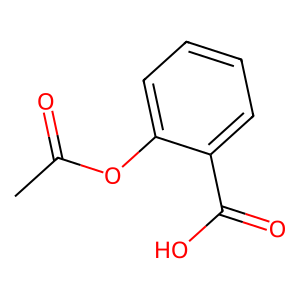

In [16]:
# Now we can visualise them 
Draw.MolToImage(aspirin)

In [17]:
# we can also get the information of molecules by calling their attribute

print(ethanol.GetAtoms())
print(ethanol.GetNumAtoms())
print(ethanol.GetBonds())
print(ethanol.GetNumBonds())
print(ethanol.GetRingInfo())

# And so manuy more attributes that we can call to get the information of the molecule

# Why can we do this ? Because molecular graphs in RDKit are Python Objects

3
2


In [18]:
# You might see that GetAtoms() and GetBonds() and GetRingInfo() are not giving a nice info. Why ?
# Because they are giving us the information of the atoms, bonds and rings in the form of a list of objects. We can call the attributes of these objects to get more information about them. 
# For example, we can call GetSymbol() to get the symbol of the atom, GetBondType() to get the type of the bond, and IsInRing() to check if an atom is in a ring or not.

ethanol.GetAtoms()[0].GetSymbol() # Get the symbol of the first atom in ethanol

'C'

In [19]:
# Well, what if we want them all ?
# We can use a for loop for this

for atom in ethanol.GetAtoms():
    print(atom.GetSymbol())

ethanol.GetBonds()[0].GetBondType() # Get the type of the first bond in ethanol

# Cool right ? GetAtoms() and GetBonds() gives us an object which is a list of objects that represents the atoms and bonds of molecules !

C
C
O


rdkit.Chem.rdchem.BondType.SINGLE

In [20]:
# Now let's make a simple pipeline for analysing a molecules structure

def molecular_analyser(molecule): # This function accepts molecule only 
    if molecule == None:
        print("molecule unrecognized")
    else:
        # Bond Structure
        print("======================================= ")
        print(f"Number of bonds: {molecule.GetNumBonds()}")
        for bond in molecule.GetBonds():
            print(bond.GetBondType())
        print("========================================")
        print(f"Number of atoms: {molecule.GetNumAtoms()}")
        for atom in molecule.GetAtoms():
            print(atom.GetSymbol())
        print("=======================================")
        img = Draw.MolToImage(molecule)
        img.show()

In [21]:
molecular_analyser(aspirin)

Number of bonds: 13
SINGLE
DOUBLE
SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
AROMATIC
AROMATIC
SINGLE
DOUBLE
SINGLE
AROMATIC
Number of atoms: 13
C
C
O
O
C
C
C
C
C
C
C
O
O


# 2. Molecular Descriptors 
Numerical properties used in modeling (but also properties of molecules in single terms)

* Molecular weights
* logP
* TPSA
* H-Bond donors 
* H-Bond acceptors
* Rotatable bonds
* Surface area

We mostly use:
* `rdkit.Chem.Descriptors`
* `rdkit.Chem.rdMolDescriptors`

In [22]:
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

In [23]:
# let's use our trusty friend aspirin !

mol = aspirin # We've made an aspirin object above in case you forgot 

print(Descriptors.MolWt(mol)) # Use to calculate molecular weight 
print(Descriptors.MolLogP(mol)) # Used to calculate logP (log of partition coeefifcient of solubility in organic (ocatane) and polar solvent(H2O))
print(rdMolDescriptors.CalcTPSA(mol)) # Used to calculate TPSA (Topological Polar Surface Area)
print(rdMolDescriptors.CalcNumHBD(mol)) # Used to calculate number of hydrogen bond donor
print(rdMolDescriptors.CalcNumHBA(mol)) # Used to calculate number of hydrogen bond acceptor 

# And so many more !

180.15899999999996
1.3101
63.60000000000001
1
3


Now what's the difference between Descriptors and rdMolDescriptors ?

Descriptors is a module that contains functions that calculate molecular descriptors that are based on the 2D structure of the molecule.

While rdMolDescriptors is a module that contains functions that calculate molecular descriptors that are based on the 3D structure of the molecule.

# 3. Structural Fingerprints
Encode molecular structure into vectors

These allows:
* Similarity search 
* Clustering 
* Machine learning

package used -> `rdkit.Chem.AllChem`

In [24]:
from rdkit.Chem import AllChem

In [25]:
fp = AllChem.GetMorganFingerprintAsBitVect(aspirin, radius=2, nBits=1024)

print(fp)

# You might see a deprecation warning, but we'll fix it after this

[16:43:12] DEPRECATION WARNING: please use MorganGenerator


In [26]:
# We can convert this into numpy (important from ML)

import numpy as np

fp_array = np.array(fp)
print(fp_array)
print(fp_array.shape)

[0 0 0 ... 0 0 0]
(1024,)


Since we got a `DEPRECATION WARNING` (meaning library is old)

We can use another python lib -> `rdkit.Chem.rdFingerPrintGenerator.GetMorganGenerator`


In [27]:
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

generator = GetMorganGenerator(radius=2, fpSize=1024) # Make generator 
fp = generator.GetFingerprint(aspirin) # insert molecule into the generator and make it output fingerprint

In [28]:
print(fp) # Will return object

In [29]:
# Converting to numpy
import numpy as np

fp_array = np.array(fp)
print(fp_array)
print(fp_array.shape)

[0 0 0 ... 0 0 0]
(1024,)


Now...what just happened ?

We essentially created an 'engine' (or a generator, yes) to create a morgan fingerprint

Instead of making a generator each time we want a fingerprint, the new method allows us to only make one engine for all molecules

# 4. Substructure Search 
Find chemical motives (functional groups, etc)

e.g
* Benzene ring 
* Carboxylic acid
* Amide group
* etc

Package used -> `rdkit.Chem`

In [30]:
# For example, we want to see if aspirin have a benzene substructure.

benzene_pattern = Chem.MolFromSmarts("c1ccccc1") # making a benzene pattern 

aspirin.HasSubstructMatch(benzene_pattern)  # See if there is a benzene pattern in it (gives True or False value)

# Note that since we only need Chem. We basically only need to call a methode(attribute) on it lol

True

In [31]:
# We can also see where the match occurs 

aspirin.GetSubstructMatches(benzene_pattern)

((4, 5, 6, 7, 8, 9),)

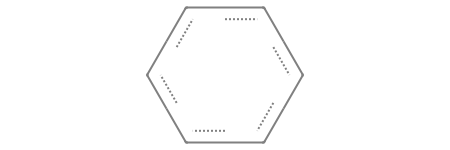

In [32]:
# Just in case you're curious about the benzene substructure

benzene_pattern

Now, what can we use this for ? 

A myriad of things actually, such as:
* Functional group detection
* Reaction Site Detection
* Scaffold search 

# 5. Similarity searching
Find molecules that resembles yours

Used for:

* Drug discovery 
* Lead Optimization
* Chemical Database Search

Packages used -> `rdkit.Datastructs` & `rdkit.Chem.AllChem` & `rdkit.Chem.rdFingerPrintGenerator.GetMorganGenerator` (newer version)

In [33]:
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

In [34]:
# We will use compare caffeine and aspirin this time
# Recall that we've made caffeine and aspirin object
# We'll use newer version

# 1) Make a fingerprint generator 

generator = GetMorganGenerator(radius=2, fpSize=1024) # Set graph detection radius as 2 and fingerprint size as 1024

# 2) Get fingerprint of molecules

fp_caffeine = generator.GetFingerprint(caffeine)
fp_aspirin = generator.GetFingerprint(aspirin)

# 3) Get similarity (we'll use Tanimoto similarity)

similarity = DataStructs.TanimotoSimilarity(fp_caffeine, fp_aspirin)

print(f"Similarity: {similarity}")

Similarity: 0.09090909090909091


How do we interpret Tanimoto similarity score ?

We usually interpret Tanimoto similarity score as:
* 0.9-1.0 -> Almost identical 
* 0.7-0.9 -> Similar Scaffold 
* 0.4-0.7 -> Moderate similarity
*   < 0.3 -> Very different 

This is usually used in:
* Drug discovery 
* Compound Screening 
* Chemical Database Search 

# 6. Chemical Database Navigation

Cheminformatics powers chemical databases

e.g.

* Pubchem
* chEMBL
* DrugBank

But what is a chemical database ? 

Well, it is essentially a collection of molecules/ molecular data stored as SMILES format or metadata

packages used -> `rdkit.Chem` & `rdkit.Chem.Descriptors`

## 6.1 Intro to database

In [35]:
# Let's try making our own database first

from rdkit import Chem

# This is the list of SMILES that we will make our database from
smiles_list = [
    "CCO", # Ethanol
    "c1ccccc1", # Benzene
    "CC(=O)OC1=CC=CC=C1C(=O)O", # Aspirin
    "Cn1cnc2c1c(=O)n(c(=O)n2C)C" # caffeine
]

In [36]:
molecules = [Chem.MolFromSmiles(mol) for mol in smiles_list]

In [37]:
# Checking the molecular database

for mols in molecules:
    print(mols)

print("Molecules checked")

# The function above returns objects

Molecules checked


In [38]:
# Tips: if you want to convert mols to smiles then you can just do Chem.MolToSmiles()

i = 0 
for mols in molecules:
    print(f"{i}. {Chem.MolToSmiles(mols)}")
    i += 1

0. CCO
1. c1ccccc1
2. CC(=O)Oc1ccccc1C(=O)O
3. Cn1c(=O)c2c(ncn2C)n(C)c1=O


In [39]:
# Now, what do we do with this ? 
# Well we can call molecules based on their properties !

for mols in molecules:
    if Descriptors.MolWt(mols) >= 100.0:
        print(f"Molecule: {Chem.MolToSmiles(mols)} is heavier than 100.0 amu")

Molecule: CC(=O)Oc1ccccc1C(=O)O is heavier than 100.0 amu
Molecule: Cn1c(=O)c2c(ncn2C)n(C)c1=O is heavier than 100.0 amu


## 6.2 Real database (API Calls)

This is gonna look scary, but trust me...it's not. You're not gonna break te internet lol

In [40]:
# Making the call
import requests

# Get aspirin info from PubChem
url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/aspirin/property/CanonicalSMILES/JSON"

response = requests.get(url)
data = response.json()

smiles = data['PropertyTable']['Properties'][0]["ConnectivitySMILES"]

print(smiles)

CC(=O)OC1=CC=CC=C1C(=O)O


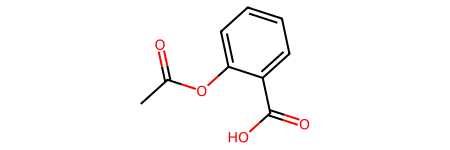

In [41]:
# Now we just need to plug it into rdkit 

from rdkit import Chem

mol = Chem.MolFromSmiles(smiles)
mol

In [42]:
# Let's make it dynamic

compound = "methamphetamine"

url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound}/property/CanonicalSMILES/JSON"

response = requests.get(url) 
data = response.json() # Turning data into json files

data["PropertyTable"]["Properties"][0]["ConnectivitySMILES"]

'CC(CC1=CC=CC=C1)NC'

In [43]:
# Let's functionize it 

def molecular_caller(compound:str):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound}/property/CanonicalSMILES/JSON"

    response = requests.get(url) 

    if response.status_code != 200:
        print("Can't access molecule")
        return None
    
    data = response.json() # Turning data into json files

    try:
        return data["PropertyTable"]["Properties"][0]["ConnectivitySMILES"]
    except:
        print("MOLECULE QUERY FAILED")
        return None    

In [44]:
print(molecular_caller("methamphetamine"))

CC(CC1=CC=CC=C1)NC


## Ending note:

APIs allows us to access large databases like pubchem instead of manually downloading assets.

So, instead of storing them locally we can query them on demand:

Pros:
* No need to store data 

Cons:
* Need internet connectivity 

# 7. Property Prediction
We can predict properties of a molecule and have machine learning models predict properties too !

e.g:
* Solubility 
* Toxicity
* Bioavailability
* Metabolic Stability 
* Blood-brain barrier barrier penetration

Now we can use the molecular descriptors we learn in chapter 2 as well !

To put it simply molecular descriptors give the numbers, now we arrange how to use those numbers !

packages used -> `rdkit.Chem` & `rdkit.Chem.Descriptor`

## 7.1 Interpretation

In [ ]:
# Let's use aspirin (we have a mol object of it)

# We're gonna get the molecular descriptors of it


print(f"Molecular weight: {Descriptors.MolWt(aspirin)}")  # Gives the molecular weight in amu
print(f"log P: {Descriptors.MolLogP(aspirin)}") # Gives the octanol-water partition coefficient (a measure of liphophilicity) 
print(f"Molecular refractive index: {Descriptors.MolMR(aspirin)}") # Gives molecular refractive index 
print(f"Number of hydrogen bond donor: {Descriptors.NumHDonors(aspirin)}") # Gives the number of hydrogen bond donor 
print(f"Number of hydrogen bond acceptor: {Descriptors.NumHAcceptors(aspirin)}") # Gives number of hydrogen bond acceptor 

Molecular weight: 180.15899999999996
log P: 1.3101
Molecular refractive index: 44.71030000000002
Number of hydrogen bond donor: 1
Number of hydrogen bond acceptor: 3


###  Now how can we utilize these informations ?

Well, there are rules in chemistry/biochemistry/drug-discovery that utilises certain rules to predict a compound behaviour

For example we can use lipinski rule of 5s: a rule-of-thumb for better absorption/permeability (drug oral bioavailability & gut absorption) in early research:
1) Molecular weight < 500 Da
2) liphophilicity (log P) < 5 (and usually above zero)
3) Hydrogen bond donor <= 5
4) Hydrogen bond acceptor <= 10


In [86]:
# Let's code a pipeline function to test a molecule

def lipinski_screener(molecule):
    """"
    Test molecule if it passes the lipinski rule of 5s

    return 1 = pass
    return 0 = not 
    
    """
    score = 0
    if Descriptors.MolWt(molecule) < 500:
        score += 1
    if 0 < Descriptors.MolLogP(molecule) < 5:
        score += 1
    if Descriptors.NumHDonors(molecule) <= 5:
        score += 1
    if Descriptors.NumHAcceptors(molecule) <= 10:
        score += 1
    if score == 4:
        return 1
    else:
        return 0


In [89]:
lipinski_screener(aspirin)

1

In [90]:
# Now let's try something 
lipinski_screener(benzene)

1

Wait, why did benzene passes the lipinski rule of 5s even though it's rather poisonous ?

Well, that's because lipinski rule of 5s only sees if it's permeable enough to pass through the gut lining

so, lipinski rule of 5s is NOT a measure of drug likeliness, only a rule of thumb

This is why we use further testing or even machine learning to predict if a drug is likely to be a drug 

## 7.2 AI/ML for molecular properties prediction 

Now we get to the good stuff.

Just earlier we turn human reasoning into code into knowledge/inference.

Now we turn data into machine reasoning into inference -> data driven logic

For now, let's start simple by predicting if a molecular descriptors in the lipinski rule of 5s is a good drug 

packages used -> `Chem.Descriptors` & `sklearn`

In [73]:
# Getting a list of molecules
molecules = [ethanol, aspirin, caffeine, benzene]

In [74]:
# Creating a training dataset
# Creating features
def featurize(mol):
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol)
    ]

X = [featurize(mol) for mol in molecules]
X

[[46.069, -0.0014000000000000123, 1, 1],
 [180.15899999999996, 1.3101, 1, 3],
 [194.194, -1.0293, 0, 3],
 [78.11399999999999, 1.6866, 0, 0]]

In [75]:
# Defining labels
y = [1, 1, 1,0]
y

[1, 1, 1, 0]

In [80]:
# Now, let's use scikit learn and the logistic regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [81]:
# Show model coefficient
print(model.coef_)

[[ 0.01051364 -0.55783722  0.34457245  0.53718255]]


In [92]:
model.predict([featurize(benzene)])

array([0])

In [ ]:
# Cool ! Now benzene is not considered drug like !
# Now to practice, try other machine learning models !

Takeaway: 

Interestingly, benzene satisfies Lipinski's rule of 5s despite not being a viable drug candidate !

This highlights the limitation of rule-based systems and motivates the use of machine learning 

### Congrats

you just made your first ai model for drug discovery !

A reminder though that this is just a simple model since the dataset is tiny !

So be sure to practice more in the future

# 8 Reaction informatics 
Analyse and simulate chemical reactions

e.g:
* Reaction templates
* Retrosynthesis
* Reaction Prediction

Reaction informatics focuses on representing and simulating chemical transformations.

Instead of analysing static molecules, we now model how molecules change through reactions.

Also, now that you've learned SMILES, we're gonna use SMARTS

SMARTS = pattern language
Reaction SMARTS = transformation rules

package used -> `rdkit.Chem.AllChem` 

In [94]:
from rdkit.Chem import AllChem

# Let's make a reaction
reaction = AllChem.ReactionFromSmarts('[C:1]=[O:2]>>[C:1][O:2]') 

# This means C=O -> C-O

In [96]:
mol = Chem.MolFromSmiles("CC=O") # Acetaldehyde

products = reaction.RunReactants((mol,))
products

((<rdkit.Chem.rdchem.Mol at 0x730bd4927a70>,),)

Reaction SMARTS define how atoms are rearrranged during a reaction.

Atoms are mapped using indices (e.g., :1, :2) allowing us to track how structures change.

More advanced applications include retrosynthesis and reaction prediction, where models learn how to generate or reverse chemical reactions.

In [98]:
# Additional: if you want to see multiple outputs

for product in products:
    print(product)

(<rdkit.Chem.rdchem.Mol object at 0x730bd4927a70>,)


# 9. Chemical Space Exploration
Chemical space represents molecules as points in a high-dimensional space based on their structural or physicochemical features

This allows us to compare, cluster, and explore molecules beyond simple visual inspection

In short,mapping molecules in high-dimensional space and seeing their differences:

used for:
* Drug discovery 
* Compound Library Design
* Lead Optimization

packages used -> `rdkit.Chem.rdFingerPrintGenerator.GetMorganGenerator` & `rdkit.DataStructs` & `numpy`

In [99]:
# We can use a morgan fingerprint generator 
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

generator = GetMorganGenerator(radius=2, fpSize=1024)


In [102]:
# Now let's compare fingerprints of aspirin and caffeine

from rdkit import DataStructs

fp1 = generator.GetFingerprint(aspirin)
fp2 = generator.GetFingerprint(caffeine)

similarity = DataStructs.TanimotoSimilarity(fp1, fp2)
print(similarity)

0.09090909090909091


We've covered the above at chapter 5. So now let's move on to the fingerprint themselves

In [107]:
import numpy as np

# Let's get aspirin's fingerprint

fp_aspirin = generator.GetFingerprint(aspirin)

fp_aspirin_array = np.array(fp)
print(fp_aspirin_array)


[0 0 0 ... 0 0 0]


### Explanation:

Earlier we made the Morgan Fingerprint Generator to have parameters: radius=2, fpsize = 1024.

Now...what does tis mean ? w

Well, we essentially told it to convert the molecule to fingerprints, starting from an atom and convert within 2 atomic radius to fingerprint then move on to the next atom.

After that we made it so that the resulting fingerprint is 1024 bit in size.

Each bit is a feature, there is 1024 dimension (hyperplane)

All those 1024 dimensions is represented as bit then stored in a 1D array

Essentially, a fingerprint is a hyperplane/high-dimension vector

So, what is similarity ?

it's a way to measure distance between 2 points in space

# 10. Dataset Generation and making AI pipelines
Chemoinformatics enables us to convert molecular structure into machine-learning ready data.

By transforming molecules into numerical representations such as descriptors or fingerprints.

We can build datasets that allow models to learn and predict molecular properties

Cheminformatics converts molecules into machine-learning-ready data.

molecules -> fingerprint -> ML models -> Activity Prediction

Now this is the amalgamation of our work

We're gonna make a machine learning model for drug likeliness

In [111]:
# Let's make a function for converting mol object into fingerprints
def morgan_fingerprint(molecule):
    generator = GetMorganGenerator(radius=2, fpSize=1024)
    fp  = generator.GetFingerprint(molecule)
    fp_array = np.array(fp)
    return fp_array

In [112]:
# Making dataset
# Feature making 

molecules = [benzene, aspirin, caffeine, ethanol]

X = [morgan_fingerprint(mol) for mol in molecules]

In [114]:
# Labels
y = [0, 1 , 1, 1]

# benzene(0), aspirin(0), caffeine(0), ethanol(0)

In [115]:
# Making and fitting the model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [118]:
pred = model.predict([morgan_fingerprint(glucose)])
print(pred)

[1]


In this workflow/pipeline:
1) The mol objects get transformed into morgan fingerprints. 
2) Labels are assigned based on drug-likeliness for each molecule (1=likely, 0=unlikely)
3) The RandomForestClassifier model is fitted 
4) Then the model is used to predict the drug likeliness

Takeaways: 

Molecular descriptors provide interpretable information of the molecule,

Fingerprints gives the vector encoding in hyper-dimensional space of the molecular structure,

Machine learning combines these representations to make predictions. 